# Interpolação de imagens utilizando correlação/convolução

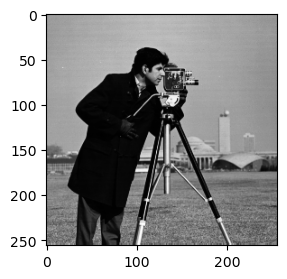

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import correlate

img = plt.imread("../../dados/cameraman.tiff")
plt.imshow(img, "gray")

In [10]:
def upsample_2x(img, filt):
    """Interpola imagem utilizando o filtro fornecido na variável filtro"""
    num_rows, num_cols = img.shape
    img_upsampled = np.zeros([2*num_rows-1, 2*num_cols-1])
    for row in range(num_rows-1):
        for col in range(num_cols-1):
            img_upsampled[2*row, 2*col] = img[row, col]
    img_upsampled[-1,::2] = img[-1]
    img_upsampled[::2,-1] = img[:,-1]

    signal_interp = correlate(img_upsampled, filt, mode="same")
    
    return signal_interp

### 1. Interpolação de vizinho mais próximo (ordem 0) utilizando um filtro caixa

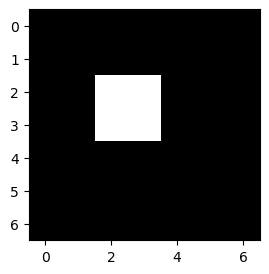

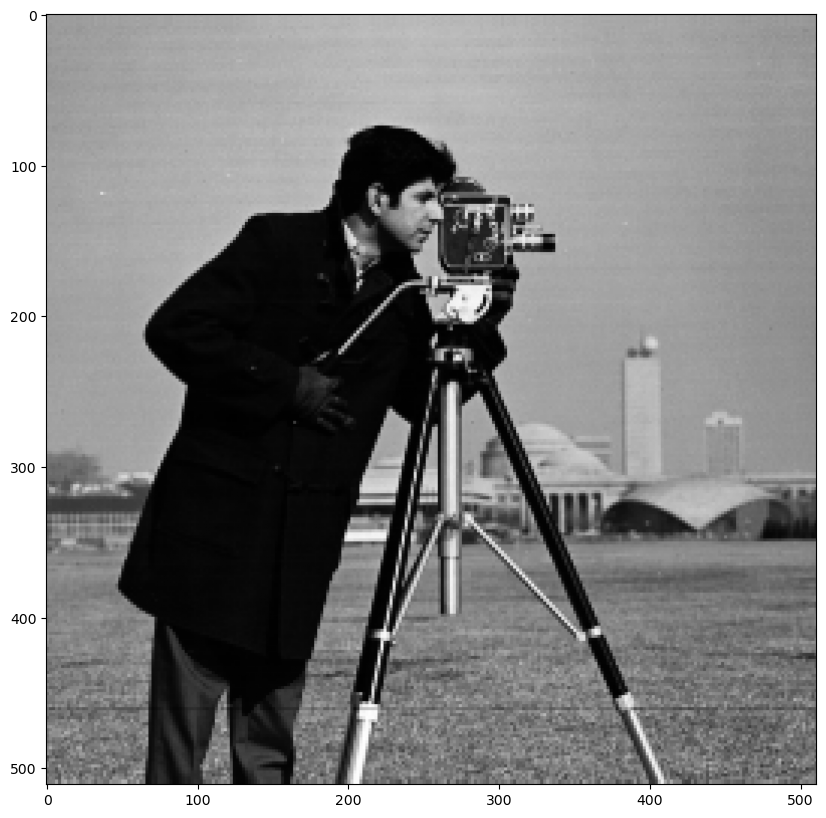

In [11]:
w = np.zeros([7,7])
w[2:4,2:4] = 1

img_interp_0 = upsample_2x(img, w)

plt.imshow(w, "gray")
plt.figure(figsize=[10, 10])
plt.imshow(img_interp_0, "gray")

É difícil notar diferenças entre a imagem original e interpolada de ordem 0 porque ambas as imagens são interpoladas pelo matplotlib no momento da visualização, utilizando interpolação de ordem 0.

### 2. Interpolação linear (ordem 1) utilizando um filtro cone, formado pela correlação entre dois filtros caixa

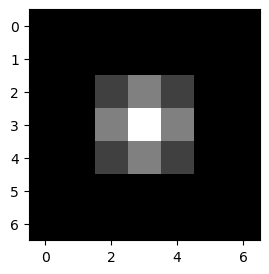

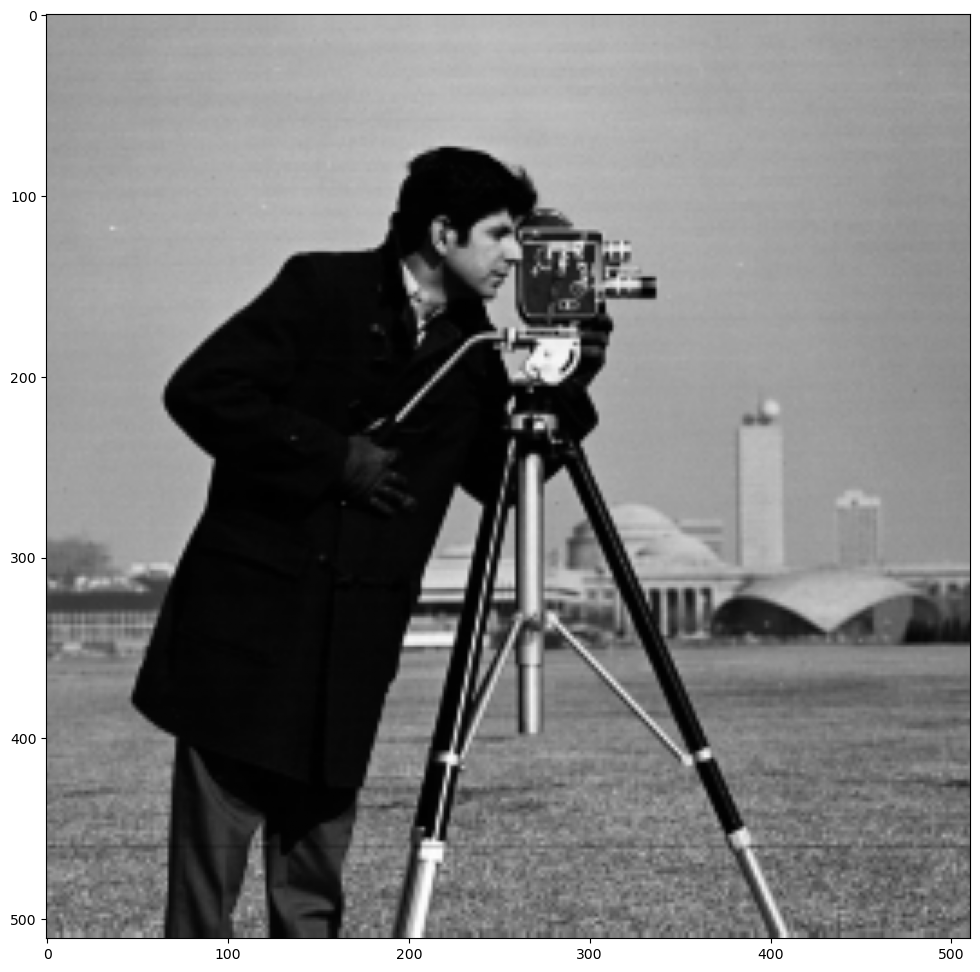

In [12]:
w2 = correlate(w, w, mode="same")
w2 = w2/4
img_interp_1 = upsample_2x(img, w2)

plt.imshow(w2, "gray")
plt.figure(figsize=[12, 12])
plt.imshow(img_interp_1, "gray")

### 3. "Interpolação" de ordem 3 utilizando um filtro formado pela correlação de dois filtros cone

Essa não é uma interpolação real, pois os valores em posições na imagem interpolda que coincidem com a imagem original não são os mesmos. 

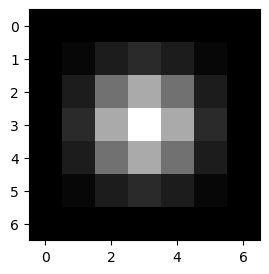

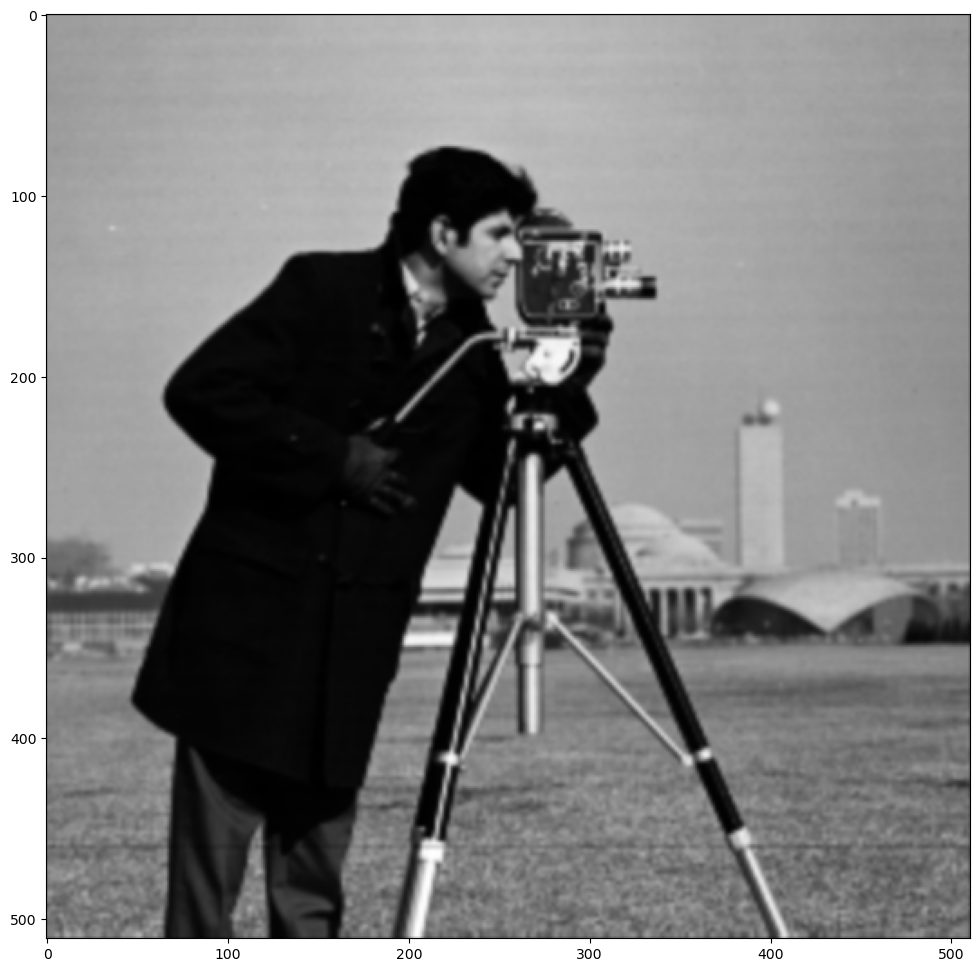

In [13]:
w3 = correlate(w2, w2, mode="same")
w3 = w3/4
img_interp_3 = upsample_2x(img, w3)

plt.imshow(w3, "gray")
plt.figure(figsize=[12, 12])
plt.imshow(img_interp_3, "gray")

### 4. Interpolação bicúbica (ordem 3) utilizando um filtro específico

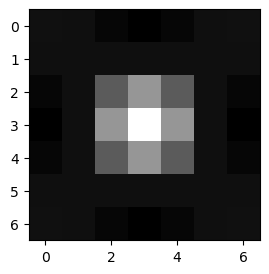

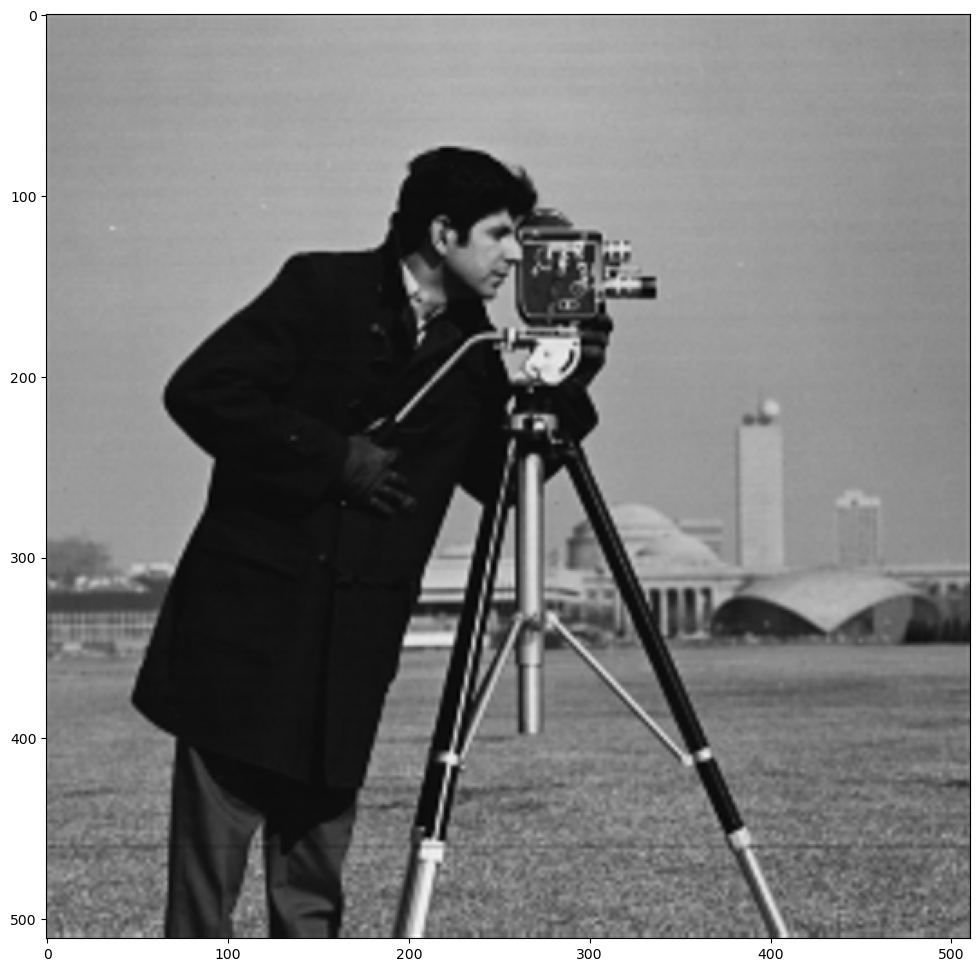

In [14]:
# Filtro de interpolação de ordem 3, conhecido como interpolação cúbica.
w_c = np.array([[-0.0625, 0, 0.5625, 1, 0.5625, 0, -0.0625]])
w_c2d = np.dot(w_c.T, w_c)
img_interp_c = upsample_2x(img, w_c2d)

plt.imshow(w_c2d, "gray")
plt.figure(figsize=[12, 12])
plt.imshow(img_interp_c, "gray")

### 5. Comparação entre os resultados das interpolações

Text(0.5, 1.0, 'Interpolação bicúbica (ordem 3)')

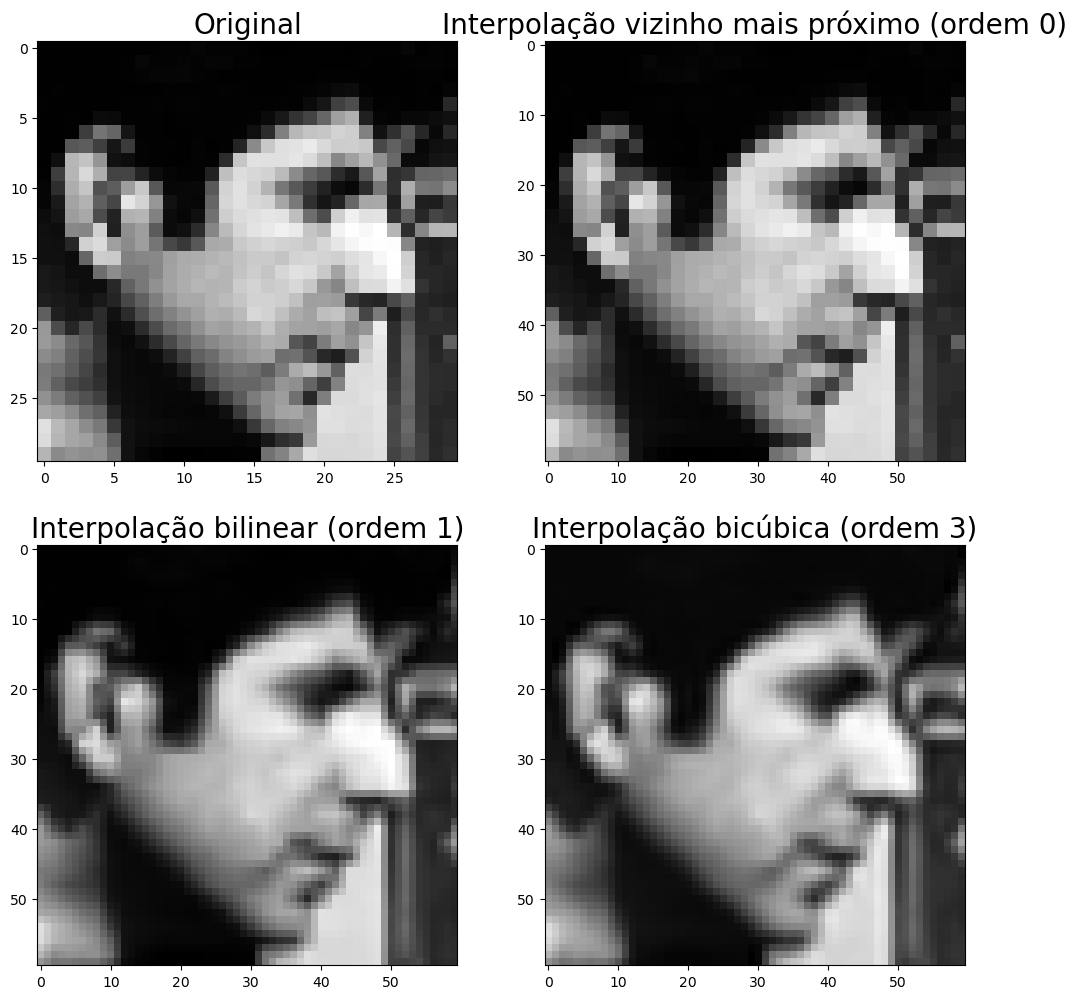

In [15]:
ri = 50
rf = 80
ci = 105
cf = 135

plt.figure(figsize=[12, 12])
plt.subplot(2, 2, 1)
plt.imshow(img[ri:rf, ci:cf], "gray")
plt.title("Original", size=20)
plt.subplot(2, 2, 2)
plt.imshow(img_interp_0[2*ri:2*rf, 2*ci:2*cf], "gray")
plt.title("Interpolação vizinho mais próximo (ordem 0)", size=20)
plt.subplot(2, 2, 3)
plt.imshow(img_interp_1[2*ri:2*rf, 2*ci:2*cf], "gray")
plt.title("Interpolação bilinear (ordem 1)", size=20)
plt.subplot(2, 2, 4)
plt.imshow(img_interp_c[2*ri:2*rf, 2*ci:2*cf], "gray")
plt.title("Interpolação bicúbica (ordem 3)", size=20)
#plt.savefig('interpolação.png', dpi=150)

Podemos interpolar novamente a imagem para obter uma nova imagem que possui 4x o tamanho da original

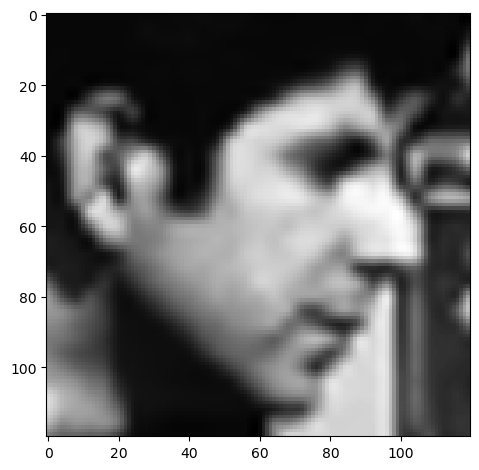

In [16]:
img_interp_c2 = upsample_2x(img_interp_c, w_c2d)
plt.figure(figsize=[5.5, 5.5])
plt.imshow(img_interp_c2[200:320, 420:540], "gray")

## Interpolação de imagens usando o scipy

A função zoom permite redimensionar uma imagem para um novo tamanho:

In [18]:
from scipy.ndimage import zoom, map_coordinates

# Cria imagem com tamanho 2.3 vezes maior que a original utilizando interpolação cúbica
img_zoom = zoom(img, zoom=2.3, order=3)
print(img_zoom.shape)

(589, 589)


A função `map_coordinates` permite calcular as intensidades em qualquer ponto dentro da imagem, mesmo que as coordenadas não sejam valores inteiros:

In [30]:
# Define coordenadas para as quais queremos obter os valores de intensidade
coords = np.array([
    [34.8,   64.32], 
    [106.32, 133.67], 
    [200.5,  30.1]
]).T

intensidades = map_coordinates(img, coords, order=3)
print(intensidades)

[174  14 137]
